# Unsupervised Learning — An Overview

**Topic:** Unsupervised Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tkh_utils import PALETTE


---
## What you'll explore

By the end of this overview you will be able to:

- **Describe** the two major categories of unsupervised learning: clustering and dimensionality reduction
- **Explain** how unsupervised learning differs from supervised learning in goals, evaluation, and application
- **Identify** which algorithm category to reach for given a specific real-world problem

> **Tip:** The category diagram below maps every algorithm in this folder to the category it belongs to. Each one solves a different kind of "find structure without labels" problem.

---
## How we got here

You have completed the **supervised/** series — you can train, evaluate, and interpret models that learn from labeled examples. But most data in the real world has no labels. No one has told you which customers are "loyal." No one has labeled which transactions are "suspicious." No one has pre-grouped your documents into topics.

**[ml_concepts/02_supervised_vs_unsupervised.ipynb](../ml_concepts/02_supervised_vs_unsupervised.ipynb)** introduced this distinction. This notebook sets the stage for a full series exploring what you can discover when there are no labels to guide you.

---
## Why this matters for data science

Most data a real organization collects is unlabeled. Customer transaction histories, website clickstreams, scientific measurements, sensor readings — none of these come with a label column. Unsupervised learning is how you extract structure, find anomalies, compress information, and discover patterns from that raw unlabeled data.

The algorithms in this folder are also the foundation for exploratory data analysis, feature engineering, and pre-processing steps that improve supervised models.

---
## See it in action

The diagram below maps the two categories of unsupervised learning covered in this folder, and which algorithms in this folder belong to each one.

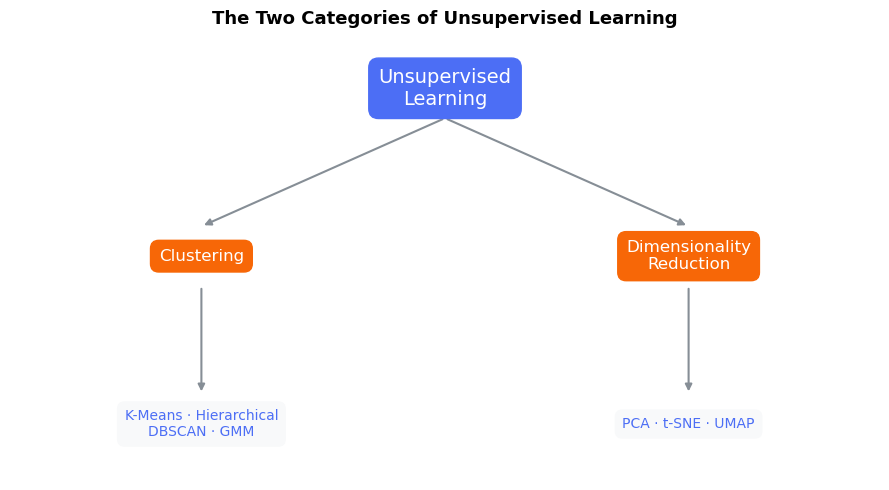

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

nodes = {
    'root': dict(x=0.5, y=1.00, text='Unsupervised\nLearning', bg=PALETTE['primary'], fg='white', size=14),
    'clustering': dict(x=0.22, y=0.55, text='Clustering', bg=PALETTE['secondary'], fg='white', size=12),
    'dimred': dict(x=0.78, y=0.55, text='Dimensionality\nReduction', bg=PALETTE['secondary'], fg='white', size=12),
    'clustering_algos': dict(x=0.22, y=0.10, text='K-Means · Hierarchical\nDBSCAN · GMM',
                              bg=PALETTE['background'], fg=PALETTE['primary'], size=10),
    'dimred_algos': dict(x=0.78, y=0.10, text='PCA · t-SNE · UMAP',
                          bg=PALETTE['background'], fg=PALETTE['primary'], size=10),
}
edges = [('root', 'clustering'), ('root', 'dimred'),
         ('clustering', 'clustering_algos'), ('dimred', 'dimred_algos')]

for start, end in edges:
    x0, y0 = nodes[start]['x'], nodes[start]['y']
    x1, y1 = nodes[end]['x'], nodes[end]['y']
    ax.annotate('', xy=(x1, y1 + 0.08), xytext=(x0, y0 - 0.08),
                arrowprops=dict(arrowstyle='-|>', color=PALETTE['muted'], lw=1.5))

for node in nodes.values():
    ax.text(node['x'], node['y'], node['text'], ha='center', va='center',
            fontsize=node['size'], color=node['fg'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor=node['bg'], edgecolor=node['bg']))

ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.15)
ax.axis('off')
ax.set_title('The Two Categories of Unsupervised Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## What's happening?

Unsupervised learning covers two distinct families of problems.

**Clustering** finds groups of similar data points without being told what the groups are. K-means, GMM, hierarchical clustering, and DBSCAN all solve this problem in different ways. Use clustering for customer segmentation, document grouping, anomaly detection as a side effect, and anywhere you want to discover natural partitions in your data.

**Dimensionality reduction** finds a compact representation of high-dimensional data that preserves the most important structure. PCA finds linear projections; t-SNE and UMAP find non-linear embeddings. Use dimensionality reduction for visualization, noise reduction, and as a preprocessing step for supervised models.

| Category | Question it answers | Key algorithms | Use when |
|----------|--------------------|-----------------|---------||
| Clustering | What groups exist? | K-means, GMM, DBSCAN | Finding natural partitions |
| Dimensionality reduction | What structure is hidden? | PCA, t-SNE, UMAP | Visualization, noise removal |

---
## Real-world example: Two Algorithms, One Dataset

The chart below applies both categories to the Mall Customers dataset: clustering finds segments, and PCA compresses the 4D data to 2D so those segments can be visualized.

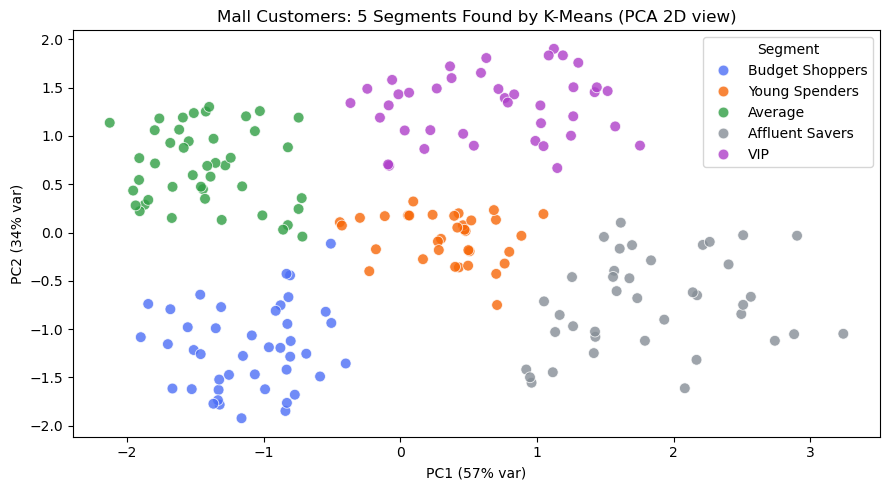

In [3]:
np.random.seed(42)
mall = pd.read_csv('../../data/mall_customers.csv')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = mall[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
X_sc = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=5, n_init=10, random_state=42)
labels = km.fit_predict(X_sc)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sc)

segment_names = ['Budget Shoppers', 'Young Spenders', 'Average', 'Affluent Savers', 'VIP']
colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['muted'], '#AE3EC9']
plot_df = pd.DataFrame({'PC1': X_2d[:, 0], 'PC2': X_2d[:, 1],
                         'Segment': [segment_names[l] for l in labels]})

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Segment', hue_order=segment_names,
                palette=colors, s=60, alpha=0.8, ax=ax)
ax.set_title('Mall Customers: 5 Segments Found by K-Means (PCA 2D view)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)')
plt.tight_layout()
plt.show()

---
## Key takeaway

> **Unsupervised learning is how you find structure in data that has no labels — and most real-world data has no labels.**

---
*Next up: 01_what_is_unsupervised_learning — the key ideas before you dive into any specific algorithm*